# Walk-Forward Optimization (WFO)

This notebook performs Walk-Forward Optimization using the `ggTrader` orchestrator api. It implements a **Robustness-First** selection strategy, picking parameters that perform consistently across multiple time folds rather than just the most recent one.

In [9]:
import sys
import os
import pandas as pd
import numpy as np
import vectorbt as vbt
import matplotlib.pyplot as plt
from tabulate import tabulate

# Auto-reload custom modules
%load_ext autoreload
%autoreload 2

# Ensure project root is in path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..',  'src'))
if project_root not in sys.path:
    sys.path.append(project_root)

from ggTrader.core.orchestrator import run_wfo_orchestrator
from ggTrader.utils.setup import load_data_and_setup
from ggTrader.utils.plotting import plot_wfo_splits
from ggTrader.core.orchestrator import run_wfo_orchestrator, run_backtest_orchestrator


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
# --- Configuration ---
CONSTANTS = {
    "SYMBOLS": None,
    "SYMBOLS_FILE": os.path.join(os.getcwd(), "..",  "data","top_25_USD_2023-01-01_2025-12-31.json"),
    "START_DATE": "2023-01-01",
    "END_DATE": "2025-12-31",
    "INTERVAL": "4h",
    "START_CASH": 1000,
    "PORTFOLIO_SHARE": .10,
    "FEES": 0.004,
    "N_SPLITS": 5,
    "TEST_RATIO": 2,  # 25% of window is test set
    "MIN_TRADES": 5,    
    "SLIPPAGE": 0.003,
    "USE_MOVERS": 0,
}


In [11]:
# --- Define Parameter Grid ---
params = {
    # entry
    "sar_acceleration": [0.02],
    "sar_maximum": [0.2],
    "use_dmp_cross": [False],
    "adx_threshold": list(range(5, 46, 5)),
    "adx_length": list(range(7, 29, 7)),
    # exit
    "atr_length": list(range(7, 29, 7)),
    "atr_multiplier": list(np.arange(0.5, 3.1, 0.5)),
}

print("Parameter grid defined.")

Parameter grid defined.


Loading data...
Starting WFO Loop (5 splits, Ratio: 2:1)...


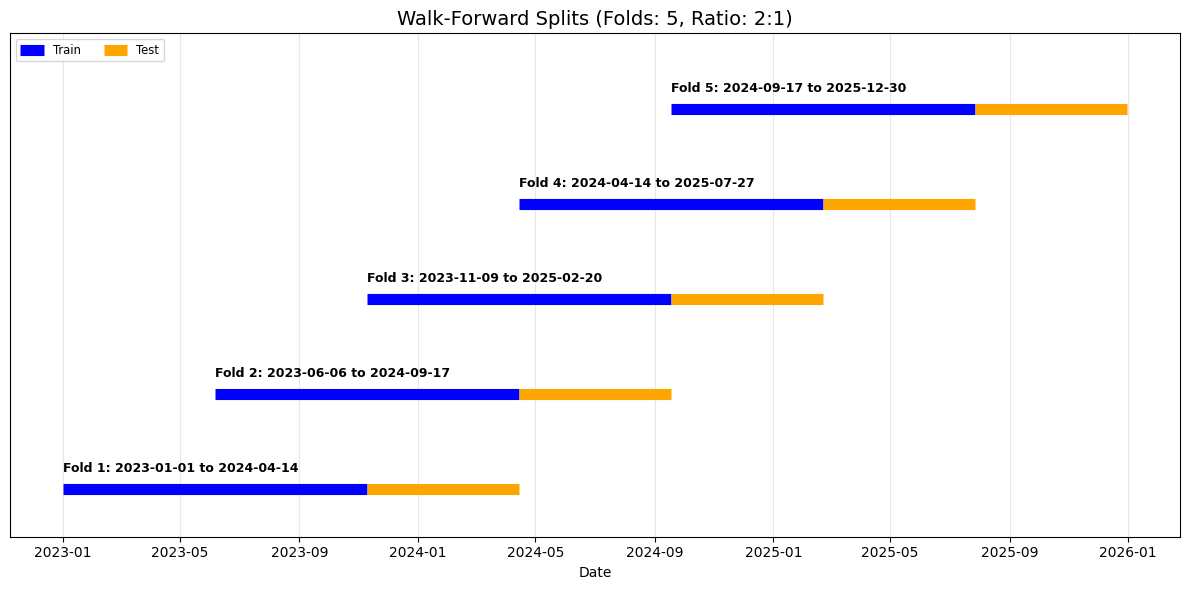

  0%|          | 0/864 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  > Fold 1 Complete.


  0%|          | 0/864 [00:00<?, ?it/s]

SystemError: CPUDispatcher(<function _atr_trailing_stop_long_ohlc_touch_2d_numba at 0x000001E089824A40>) returned a result with an exception set

In [12]:
# --- Run WFO ---
results = run_wfo_orchestrator(
    config=CONSTANTS, 
    param_grid=params, 
    save_results=False,
    show_progress=True
)

wfo_stats = results["wfo_stats"]
robust_top_5 = results["robust_top_5"]
final_pf = results["final_portfolio"]

print("\nWFO Complete.")

In [ ]:
# --- Analysis & Visualization ---

print("\nPARAMETER ROBUSTNESS REPORT (Top 5 Overall):")
robust_report_df = pd.DataFrame([{"Score": r["robustness_score"], **r["params"]} for r in robust_top_5])
print(tabulate(robust_report_df.round(2), headers="keys", tablefmt="github", showindex=False))

print("\nWFO FOLD RESULTS SUMMARY:")
df_results = pd.DataFrame(wfo_stats)
# Create a concise string for the best params
def simplify_params(d):
    # Only show the params that usually change (e.g., adx and atr)
    return f"ADX:{d.get('adx_threshold')}/{d.get('adx_length')} | ATR:{d.get('atr_multiplier'):.2f}"

df_clean = df_results.copy()
df_clean['params'] = df_clean['params'].apply(simplify_params)
df_clean['train'] = pd.to_datetime(df_clean['train_start']).dt.strftime('%Y-%m-%d')
df_clean['test'] = pd.to_datetime(df_clean['test_start']).dt.strftime('%Y-%m-%d')

# Select only the readable columns
cols = ['fold', 'train', 'test', 'params', 'is_sharpe', 'oos_sharpe', 'profit']
print(tabulate(df_clean[cols].round(2), headers='keys', tablefmt='github', showindex=False))




PARAMETER ROBUSTNESS REPORT (Top 5 Overall):
|   Score |   adx_length |   adx_threshold |   sar_acceleration |   sar_maximum |   use_dmp_cross |   atr_length |   atr_multiplier |
|---------|--------------|-----------------|--------------------|---------------|-----------------|--------------|------------------|
|     0.4 |           10 |               5 |               0.02 |           0.2 |               0 |            5 |             0.02 |
|     0.4 |           10 |               5 |               0.02 |           0.2 |               0 |            5 |             0.04 |
|     0.4 |           10 |               5 |               0.02 |           0.2 |               0 |            5 |             0.06 |
|     0.4 |           10 |               5 |               0.02 |           0.2 |               0 |            5 |             0.07 |
|     0.4 |           10 |               5 |               0.02 |           0.2 |               0 |           10 |             0.07 |

WFO FOLD RESULT

In [ ]:

# --- Visualization ---
print("Global Portfolio Stats:")
# Convert stats to a DataFrame for a cleaner table view
stats_df = final_pf.stats().to_frame(name="Value").reset_index()

# 2. Format only the numbers to 2 decimals (ignoring dates and durations)
def format_values(x):
    if isinstance(x, (float, np.floating)):
        return f"{x:.2f}"
    return str(x)
stats_df["Value"] = stats_df["Value"].apply(format_values)

# 3. Print with tabulate (no floatfmt needed now because we formatted them in step 2)
print(tabulate(stats_df, headers=["Metric", "Value"], tablefmt="simple", numalign="right", showindex=False))


Global Portfolio Stats:
Metric                      Value
--------------------------  -------------------------
Start                       2023-01-01 00:00:00+00:00
End                         2025-12-30 16:00:00+00:00
Period                      1094 days 08:00:00
Start Value                 1000.00
End Value                   1016.08
Total Return [%]            1.61
Benchmark Return [%]        296.13
Max Gross Exposure [%]      64.02
Total Fees Paid             263.65
Max Drawdown [%]            29.52
Max Drawdown Duration       667 days 12:00:00
Total Trades                563
Total Closed Trades         558
Total Open Trades           5
Open Trade PnL              95.51
Win Rate [%]                34.77
Best Trade [%]              131.64
Worst Trade [%]             -28.18
Avg Winning Trade [%]       8.74
Avg Losing Trade [%]        -4.91
Avg Winning Trade Duration  7 days 22:19:47.628865979
Avg Losing Trade Duration   5 days 05:05:16.483516483
Profit Factor               0.93
Expe

In [ ]:
print("\nBest Params:")
print(tabulate(
    results["best_robust_params"].items(), 
    headers=["Parameter", "Value"], 
    tablefmt="simple"
))
print("\nFinal Model Performance (Full History with Best Robust Params):")
final_pf.plot(subplots= ['drawdowns','value','cum_returns']).show()


Best Params:
Parameter           Value
----------------  -------
adx_length         10
adx_threshold       5
sar_acceleration    0.02
sar_maximum         0.2
use_dmp_cross       0
atr_length          5
atr_multiplier      0.025

Final Model Performance (Full History with Best Robust Params):


In [ ]:

# 1. Run backtest for just BTC
btc_pf = run_backtest_orchestrator(
    config={**CONSTANTS, 
    "SYMBOLS": ["BTC"],
    "PORTFOLIO_SHARE": 1,
    "USE_CASH_SHARING": False,
    "group_by": False}, 
    params=results["best_robust_params"], 
    save_results=False,
    show_progress=True,
)["portfolio"]


# --- Visualization ---
print("Global Portfolio Stats:")
# Convert stats to a DataFrame for a cleaner table view
stats_df = btc_pf.stats().to_frame(name="Value").reset_index()

# 2. Format only the numbers to 2 decimals (ignoring dates and durations)
def format_values(x):
    if isinstance(x, (float, np.floating)):
        return f"{x:.2f}"
    return str(x)
stats_df["Value"] = stats_df["Value"].apply(format_values)

# 3. Print with tabulate (no floatfmt needed now because we formatted them in step 2)
print(tabulate(stats_df, headers=["Metric", "Value"], tablefmt="simple", numalign="right", showindex=False))


---------------  -----------------------------------------------------------------------------------------------
SYMBOLS
SYMBOLS_FILE     c:\Users\gkuep\PycharmProjects\ggTrader\notebooks\..\data\top_10_USD_2023-01-01_2025-12-31.json
START_DATE       2023-01-01
END_DATE         2025-12-31
INTERVAL         4h
START_CASH       1000
PORTFOLIO_SHARE  0.1
FEES             0.004
N_SPLITS         3
TEST_RATIO       3
MIN_TRADES       10
SLIPPAGE         0.003
USE_MOVERS       0
---------------  -----------------------------------------------------------------------------------------------
Loading data...
Running backtest...


  0%|          | 0/1 [00:00<?, ?it/s]

Global Portfolio Stats:
Metric                      Value
--------------------------  -------------------------
Start                       2023-01-01 00:00:00+00:00
End                         2025-12-30 16:00:00+00:00
Period                      1094 days 04:00:00
Start Value                 1000.00
End Value                   452.34
Total Return [%]            -54.77
Benchmark Return [%]        433.46
Max Gross Exposure [%]      100.00
Total Fees Paid             1099.11
Max Drawdown [%]            74.34
Max Drawdown Duration       665 days 08:00:00
Total Trades                134.00
Total Closed Trades         133.00
Total Open Trades           1.00
Open Trade PnL              -2.06
Win Rate [%]                33.08
Best Trade [%]              26.12
Worst Trade [%]             -21.21
Avg Winning Trade [%]       6.38
Avg Losing Trade [%]        -3.75
Avg Winning Trade Duration  9 days 04:10:54.545454545
Avg Losing Trade Duration   4 days 15:06:04.044943820
Profit Factor             

C:\Users\gkuep\AppData\Local\Temp\ipykernel_15516\1285579066.py:20: UserWarning:

Object has multiple columns. Aggregating using <function mean at 0x000001EBCFD553A0>. Pass column to select a single column/group.



In [ ]:
# Plot and view stats as usual
btc_pf.iloc[0].plot().show()